In [1]:
import numpy as np
import pandas as pd

# Cargar el array desde el archivo .npy
data = np.load('/Volumes/copia seguridad1/TFG_Prueba/Datos_iniciales/windows_partitioned/by_transect/dl/Transecto_1/test_X.npy')

# Convertir a DataFrame de pandas (opcional, pero facilita el guardado)
df = pd.DataFrame(data)

# analizar el DataFrame
df.info()

#


ValueError: Must pass 2-d input. shape=(4250, 72, 23)

In [2]:
import numpy as np
import pandas as pd

# 1. Cargar el array .npy
ruta = '/Volumes/copia seguridad1/TFG_Prueba/Datos_iniciales/windows_partitioned/by_transect/dl/Transecto_1/test_X.npy'
data = np.load(ruta)

print("Dimensiones originales:", data.shape)

# 2. Si es 3D (n_muestras, 72, n_features), aplanar a 2D (n_muestras, 72 * n_features)
if data.ndim == 3:
    n_muestras, pasos, n_features = data.shape
    data_2d = data.reshape(n_muestras, pasos * n_features)
    print(f"Reestructurado a 2D: {data_2d.shape} (filas, columnas)")
else:
    data_2d = data

# 3. Convertir a DataFrame
df = pd.DataFrame(data_2d)

# 4. Información general
print("\n" + "="*50)
print("RESUMEN GENERAL DEL DATAFRAME")
print("="*50)
print(f"Número de filas (muestras): {df.shape[0]}")
print(f"Número de columnas (variables): {df.shape[1]}")
print("\nTipos de datos por columna:")
print(df.dtypes.value_counts())
print("\nValores nulos por columna (primeras 10):")
print(df.isnull().sum().head(10))
if df.isnull().sum().sum() > 0:
    print(f"Total de valores nulos: {df.isnull().sum().sum()}")

# 5. Estadísticas descriptivas básicas (para todas las columnas)
print("\n" + "="*50)
print("ESTADÍSTICAS DESCRIPTIVAS")
print("="*50)
# describe() por defecto solo para columnas numéricas
desc = df.describe(percentiles=[0.01,.25, .5, .75, 0.99]).transpose()
print(desc)

# 6. (Opcional) Guardar el resumen en un CSV
desc.to_csv('resumen_estadistico.csv')
print("\nResumen guardado como 'resumen_estadistico.csv'")

# 7. (Opcional) Mostrar matriz de correlación (si no hay demasiadas columnas)
if df.shape[1] <= 20:
    print("\n" + "="*50)
    print("MATRIZ DE CORRELACIÓN (primeras 20 columnas)")
    print("="*50)
    corr = df.corr()
    print(corr)
else:
    print("\nDemasiadas columnas para mostrar correlación completa.")

Dimensiones originales: (4250, 72, 23)
Reestructurado a 2D: (4250, 1656) (filas, columnas)

RESUMEN GENERAL DEL DATAFRAME
Número de filas (muestras): 4250
Número de columnas (variables): 1656

Tipos de datos por columna:
float32    1656
Name: count, dtype: int64

Valores nulos por columna (primeras 10):
0    0
1    0
2    0
3    0
4    0
5    0
6    0
7    0
8    0
9    0
dtype: int64

ESTADÍSTICAS DESCRIPTIVAS
       count      mean       std       min        1%       25%       50%  \
0     4250.0  0.011373  0.026874  0.000000  0.000000  0.004107  0.005476   
1     4250.0  0.065359  0.094286  0.000000  0.003547  0.012821  0.025641   
2     4250.0  0.025420  0.039810  0.002041  0.002041  0.007143  0.011224   
3     4250.0  0.365536  0.151462  0.004425  0.037611  0.247788  0.383850   
4     4250.0  0.133903  0.135299  0.005051  0.005051  0.030303  0.085859   
...      ...       ...       ...       ...       ...       ...       ...   
1651  4250.0  1.000000  0.000000  1.000000  1.000000 

In [ ]:
# Guardar como CSV
df.to_csv('archivo.csv', index=False)

# Ver si hay NAN

In [9]:
import pandas as pd
import os
import sys

def revisar_nan_en_csv(rutas_archivos):
    """
    Revisa valores NaN en cada columna de uno o más archivos CSV.
    
    Parámetros:
    rutas_archivos (list): Lista de rutas a archivos CSV.
    """
    for ruta in rutas_archivos:
        if not os.path.exists(ruta):
            print(f"⚠️  Archivo no encontrado: {ruta}")
            continue
        
        try:
            # Intentar leer el CSV con codificación UTF-8; si falla, probar latin1
            df = pd.read_csv(ruta, encoding='utf-8')
        except UnicodeDecodeError:
            df = pd.read_csv(ruta, encoding='latin1')
        except Exception as e:
            print(f"❌ Error al leer {ruta}: {e}")
            continue
        
        print(f"\n📁 Archivo: {os.path.basename(ruta)}")
        
        # Verificar si hay al menos un NaN en todo el DataFrame
        if df.isna().any().any():
            # Iterar sobre cada columna que tenga al menos un NaN
            for col in df.columns[df.isna().any()]:
                # Obtener índices (0-based) donde la columna es NaN
                filas_nan = df[df[col].isna()].index.tolist()
                # Convertir a 1-based para facilidad del usuario
                filas_nan_1based = [f+1 for f in filas_nan]
                print(f"   🔸 Columna '{col}': filas {filas_nan_1based}")
        else:
            print("   ✅ No se encontraron valores NaN en este archivo.")

if __name__ == "__main__":
    # Ejemplo de uso: lista de rutas a tus archivos CSV
    archivos_csv = [
        "/Volumes/copia seguridad1/Imputed_Transect/Transecto_1.csv",
        "/Volumes/copia seguridad1/Imputed_Transect/Transecto_2.csv",
        "/Volumes/copia seguridad1/Imputed_Transect/Transecto_3.csv",
        "/Volumes/copia seguridad1/Imputed_Transect/Transecto_4.csv",
        "/Volumes/copia seguridad1/Imputed_Transect/Transecto_6.csv",
        "/Volumes/copia seguridad1/Imputed_Transect/Transecto_7.csv",
        "/Volumes/copia seguridad1/Imputed_Transect/Transecto_8.csv",
    
     ]
    
    # También podrías tomar las rutas desde argumentos de línea de comandos:
    # archivos_csv = sys.argv[1:] if len(sys.argv) > 1 else archivos_csv
    
    revisar_nan_en_csv(archivos_csv)


📁 Archivo: Transecto_1.csv
   ✅ No se encontraron valores NaN en este archivo.

📁 Archivo: Transecto_2.csv
   ✅ No se encontraron valores NaN en este archivo.

📁 Archivo: Transecto_3.csv
   ✅ No se encontraron valores NaN en este archivo.

📁 Archivo: Transecto_4.csv
   ✅ No se encontraron valores NaN en este archivo.

📁 Archivo: Transecto_6.csv
   ✅ No se encontraron valores NaN en este archivo.

📁 Archivo: Transecto_7.csv
   ✅ No se encontraron valores NaN en este archivo.

📁 Archivo: Transecto_8.csv
   ✅ No se encontraron valores NaN en este archivo.


# Quitar Columnas extra

In [8]:
import pandas as pd
import os

# Lista de rutas de archivos CSV de entrada
archivos_csv = [
    "/Volumes/copia seguridad1/imputed_transect/Transecto_1.csv",
    "/Volumes/copia seguridad1/imputed_transect/Transecto_2.csv",
    "/Volumes/copia seguridad1/imputed_transect/Transecto_3.csv",
    "/Volumes/copia seguridad1/imputed_transect/Transecto_4.csv",
    "/Volumes/copia seguridad1/imputed_transect/Transecto_6.csv",
    "/Volumes/copia seguridad1/imputed_transect/Transecto_7.csv",
    "/Volumes/copia seguridad1/imputed_transect/Transecto_8.csv",
]

# Ruta de salida
output_dir = "/Volumes/copia seguridad1/Imputed_Transect"

# Crear el directorio de salida si no existe
os.makedirs(output_dir, exist_ok=True)

# Columnas a eliminar (pueden aparecer múltiples veces)
columnas_a_eliminar = {"physical_error", "physical_reason", "outlier_stl", "outlier_jump", "outlier_iso", "sensor_error", "evento_real", "doubtful", "Pres."}

# Procesar cada archivo
for archivo in archivos_csv:
    try:
        # Leer el archivo CSV
        df = pd.read_csv(archivo)
        
        # Identificar las columnas que coinciden con las que queremos eliminar
        columnas_existentes = df.columns.tolist()
        columnas_a_quitar = [col for col in columnas_existentes if col in columnas_a_eliminar]
        
        if columnas_a_quitar:
            # Eliminar las columnas
            df = df.drop(columns=columnas_a_quitar)
            print(f"Archivo {os.path.basename(archivo)}: eliminadas {len(columnas_a_quitar)} columna(s) ({', '.join(set(columnas_a_quitar))})")
        else:
            print(f"Archivo {os.path.basename(archivo)}: no se encontraron columnas para eliminar")
        
        # Construir la ruta de salida (mismo nombre en la nueva carpeta)
        nombre_archivo = os.path.basename(archivo)
        ruta_salida = os.path.join(output_dir, nombre_archivo)
        
        # Guardar el DataFrame resultante
        df.to_csv(ruta_salida, index=False)
        print(f"Guardado en: {ruta_salida}\n")
        
    except FileNotFoundError:
        print(f"Error: No se encontró el archivo {archivo}\n")
    except Exception as e:
        print(f"Error al procesar {archivo}: {e}\n")

Archivo Transecto_1.csv: eliminadas 9 columna(s) (outlier_jump, Pres., outlier_stl, sensor_error, outlier_iso, evento_real, doubtful, physical_error, physical_reason)
Guardado en: /Volumes/copia seguridad1/Imputed_Transect/Transecto_1.csv

Archivo Transecto_2.csv: eliminadas 9 columna(s) (outlier_jump, Pres., outlier_stl, sensor_error, outlier_iso, evento_real, doubtful, physical_error, physical_reason)
Guardado en: /Volumes/copia seguridad1/Imputed_Transect/Transecto_2.csv



/var/folders/y_/8n8k4c3130sbkdjs9tb0_pv80000gp/T/ipykernel_80622/4167512552.py:28: DtypeWarning: Columns (0: physical_reason) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(archivo)


Archivo Transecto_3.csv: eliminadas 9 columna(s) (outlier_jump, Pres., outlier_stl, sensor_error, outlier_iso, evento_real, doubtful, physical_error, physical_reason)
Guardado en: /Volumes/copia seguridad1/Imputed_Transect/Transecto_3.csv



/var/folders/y_/8n8k4c3130sbkdjs9tb0_pv80000gp/T/ipykernel_80622/4167512552.py:28: DtypeWarning: Columns (0: physical_reason) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(archivo)


Archivo Transecto_4.csv: eliminadas 9 columna(s) (outlier_jump, Pres., outlier_stl, sensor_error, outlier_iso, evento_real, doubtful, physical_error, physical_reason)
Guardado en: /Volumes/copia seguridad1/Imputed_Transect/Transecto_4.csv



/var/folders/y_/8n8k4c3130sbkdjs9tb0_pv80000gp/T/ipykernel_80622/4167512552.py:28: DtypeWarning: Columns (0: physical_error, 1: outlier_stl, 2: outlier_jump, 3: outlier_iso, 4: sensor_error, 5: evento_real, 6: doubtful) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(archivo)


Archivo Transecto_6.csv: eliminadas 9 columna(s) (outlier_jump, Pres., outlier_stl, sensor_error, outlier_iso, evento_real, doubtful, physical_error, physical_reason)
Guardado en: /Volumes/copia seguridad1/Imputed_Transect/Transecto_6.csv

Archivo Transecto_7.csv: eliminadas 1 columna(s) (Pres.)
Guardado en: /Volumes/copia seguridad1/Imputed_Transect/Transecto_7.csv

Archivo Transecto_8.csv: eliminadas 1 columna(s) (Pres.)
Guardado en: /Volumes/copia seguridad1/Imputed_Transect/Transecto_8.csv



# Mirar distrubucion predicciones

Train O3: min = 1.6666666 max = 152.33333
Test  O3: min = 2.3333333 max = 130.33333


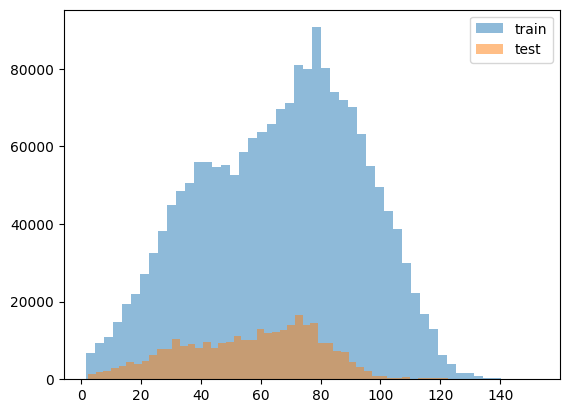

In [1]:
import numpy as np

train_y = np.load("/Volumes/copia seguridad1/TFG_Prueba/Datos_iniciales/windows_partitioned/by_transect/ml/Transecto_1/ml_2d/train_y.npy")
test_y  = np.load("/Volumes/copia seguridad1/TFG_Prueba/Datos_iniciales/windows_partitioned/by_transect/ml/Transecto_1/ml_2d/test_y.npy")

print("Train O3: min =", train_y.min(), "max =", train_y.max())
print("Test  O3: min =", test_y.min(),  "max =", test_y.max())
import matplotlib.pyplot as plt
plt.hist(train_y.ravel(), bins=50, alpha=0.5, label='train')
plt.hist(test_y.ravel(), bins=50, alpha=0.5, label='test')
plt.legend()
plt.show()